# AzuaHousing.API

This notebook demonstrates the internal Python API (`azua_utils.py`) and runs:

- Dataset download (Kaggle Melbourne Housing Snapshot)
- Data loading + light feature engineering
- Cross-validation model comparison
- Visual comparison plots (RMSE/R²)
- Fit best model on full training set, evaluate on held-out test set
- Save artifacts to `artifacts/`

**Default dataset path**: `data/melb_data.csv`.


In [1]:
import os, shutil, math
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from azua_utils import load_melbourne, train_select_best, save_artifacts

## Download dataset to `data/`

We download the Kaggle dataset using `kagglehub`, then copy `melb_data.csv` into `./data`.
If the file already exists, we reuse it.


In [2]:
os.makedirs("data", exist_ok=True)
dst = Path("data") / "melb_data.csv"

if not dst.exists():
    cache_dir = Path(kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot"))
    print("cache_dir:", cache_dir)
    src = next(cache_dir.rglob("melb_data.csv"))
    shutil.copyfile(src, dst)
    print("saved:", dst, "| size:", dst.stat().st_size)
else:
    print("found existing:", dst, "| size:", dst.stat().st_size)

found existing: data/melb_data.csv | size: 2091239


## Load dataset

The loader drops rows missing `Price` and, if a `Date` column exists, adds `Year` and `Month` features.


In [3]:
DATA_PATH = os.environ.get("DATA_PATH", "data/melb_data.csv")
print("DATA_PATH =", DATA_PATH)

df_raw = load_melbourne(DATA_PATH)
print("raw shape:", df_raw.shape)
df_raw.head()

DATA_PATH = data/melb_data.csv
raw shape: (13580, 22)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Year,Month
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2.5,3067.0,2.0,...,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,2016.0,3.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2.5,3067.0,2.0,...,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,2016.0,4.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2.5,3067.0,3.0,...,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,2017.0,4.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2.5,3067.0,3.0,...,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,2017.0,4.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2.5,3067.0,3.0,...,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,2016.0,4.0


## Compute stats (raw)

We compute basic dataset health checks (shape, duplicates, missingness) and summarize the target distribution.


,value
rows,1.358000e+04
cols,2.200000e+01
duplicates,8.000000e+00
num_cols,1.500000e+01
cat_cols,7.000000e+00
target_missing,0.000000e+00
target_mean,1.075684e+06
target_std,6.393107e+05
target_min,8.500000e+04
target_max,9.000000e+06


,missing_%
Year,62.164948
Month,62.164948
BuildingArea,47.496318
YearBuilt,39.580265
CouncilArea,10.081001
Car,0.456554


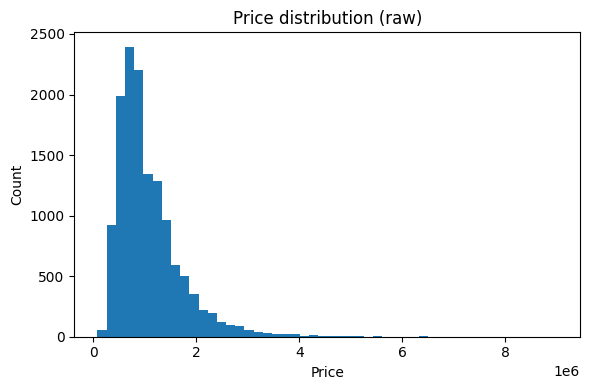

In [4]:
import numpy as np
from IPython.display import display

def compute_basic_stats(df: pd.DataFrame, target: str = "Price", top_missing: int = 12):
    stats = {
        "rows": int(df.shape[0]),
        "cols": int(df.shape[1]),
        "duplicates": int(df.duplicated().sum()),
        "num_cols": int(df.select_dtypes(include=[np.number]).shape[1]),
        "cat_cols": int(df.select_dtypes(exclude=[np.number]).shape[1]),
    }
    if target in df.columns:
        stats["target_missing"] = int(df[target].isna().sum())
        stats["target_mean"] = float(df[target].mean())
        stats["target_std"] = float(df[target].std())
        stats["target_min"] = float(df[target].min())
        stats["target_max"] = float(df[target].max())
    missing = df.isna().mean().sort_values(ascending=False) * 100.0
    missing_tbl = missing[missing > 0].head(top_missing).to_frame("missing_%")
    return pd.Series(stats), missing_tbl

raw_stats, raw_missing = compute_basic_stats(df_raw, target="Price")
display(raw_stats.to_frame("value"))
display(raw_missing)

plt.figure(figsize=(6, 4))
plt.hist(df_raw["Price"].dropna().astype(float), bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price distribution (raw)")
plt.tight_layout()
plt.show()

## Clean data

We apply conservative cleaning:
- Drop exact duplicate rows.
- Coerce selected numeric columns to numeric (invalid values become NaN).
- Replace negative values in fields that must be non-negative with NaN.
- Apply sanity bounds to `YearBuilt` (invalid values become NaN).

We keep rows whenever possible (imputers in the pipeline handle remaining missing values).


In [5]:
def clean_melbourne_df(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    df2 = df2.drop_duplicates()

    # Coerce common numeric columns (errors become NaN).
    coerce_cols = ["Postcode", "Propertycount", "YearBuilt", "Car", "Bathroom", "Bedroom2", "Rooms",
                   "Distance", "Landsize", "BuildingArea", "Year", "Month"]
    for col in coerce_cols:
        if col in df2.columns:
            df2[col] = pd.to_numeric(df2[col], errors="coerce")

    # Non-negative sanity checks: invalid negatives -> NaN (not dropped).
    nonneg_cols = ["Distance", "Landsize", "BuildingArea", "Car", "Bathroom", "Bedroom2", "Rooms"]
    for col in nonneg_cols:
        if col in df2.columns:
            df2.loc[df2[col] < 0, col] = np.nan

    # YearBuilt sanity bounds -> NaN
    if "YearBuilt" in df2.columns:
        year_now = pd.Timestamp.today().year
        df2.loc[(df2["YearBuilt"] < 1800) | (df2["YearBuilt"] > year_now + 1), "YearBuilt"] = np.nan

    # Safety: ensure target present
    if "Price" in df2.columns:
        df2 = df2.dropna(subset=["Price"])

    return df2

df = clean_melbourne_df(df_raw)
print("clean shape:", df.shape)
df.head()

clean shape: (13572, 22)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Year,Month
0,Abbotsford,85 Turner St,2.0,h,1480000.0,S,Biggin,2.5,3067.0,2.0,...,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,2016.0,3.0
1,Abbotsford,25 Bloomburg St,2.0,h,1035000.0,S,Biggin,2.5,3067.0,2.0,...,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,2016.0,4.0
2,Abbotsford,5 Charles St,3.0,h,1465000.0,SP,Biggin,2.5,3067.0,3.0,...,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,2017.0,4.0
3,Abbotsford,40 Federation La,3.0,h,850000.0,PI,Biggin,2.5,3067.0,3.0,...,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,2017.0,4.0
4,Abbotsford,55a Park St,4.0,h,1600000.0,VB,Nelson,2.5,3067.0,3.0,...,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,2016.0,4.0


## Compute stats (cleaned)

We recompute the same statistics after cleaning to verify changes.


,value
rows,1.357200e+04
cols,2.200000e+01
duplicates,0.000000e+00
num_cols,1.500000e+01
cat_cols,7.000000e+00
target_missing,0.000000e+00
target_mean,1.075684e+06
target_std,6.394321e+05
target_min,8.500000e+04
target_max,9.000000e+06


,missing_%
Year,62.142647
Month,62.142647
BuildingArea,47.502210
YearBuilt,39.588859
CouncilArea,10.086944
Car,0.456823


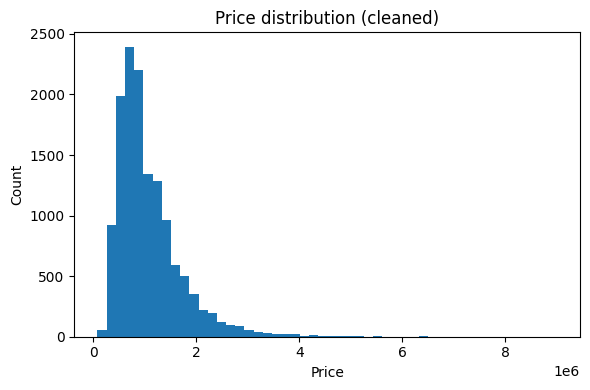

In [6]:
clean_stats, clean_missing = compute_basic_stats(df, target="Price")
display(clean_stats.to_frame("value"))
display(clean_missing)

plt.figure(figsize=(6, 4))
plt.hist(df["Price"].dropna().astype(float), bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price distribution (cleaned)")
plt.tight_layout()
plt.show()

## Train/test split

We keep a held-out test set for final evaluation.


In [7]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("train:", train_df.shape, "test:", test_df.shape)

train: (10857, 22) test: (2715, 22)


## Model comparison

We evaluate multiple regression algorithms via cross-validation:

- Linear Regression
- ElasticNet
- Random Forest
- XGBoost

We select the best model by lowest CV RMSE, then fit it on all training data.


In [8]:
bundle = train_select_best(
    train_df,
    folds=5,
    progress=True,
    fold_progress=True,
    return_folds=False
)

results = pd.DataFrame(bundle["all_results"]).sort_values("rmse").reset_index(drop=True)

Model selection (CV): 100%|██████████| 4/4 [06:48<00:00, 102.06s/it]


In [9]:
results[["model", "rmse", "rmse_std", "r2", "r2_std"]]

,model,rmse,rmse_std,r2,r2_std
0,xgb,273523.731769,15161.044188,0.814895,0.021344
1,rf,291868.352420,16118.064914,0.789273,0.023809
2,linreg,456125.396327,180645.146455,0.406817,0.559093
3,elastic,470482.062547,215395.983009,0.342630,0.708653


## Comparison plots

We generate plots and save them under `artifacts/`.


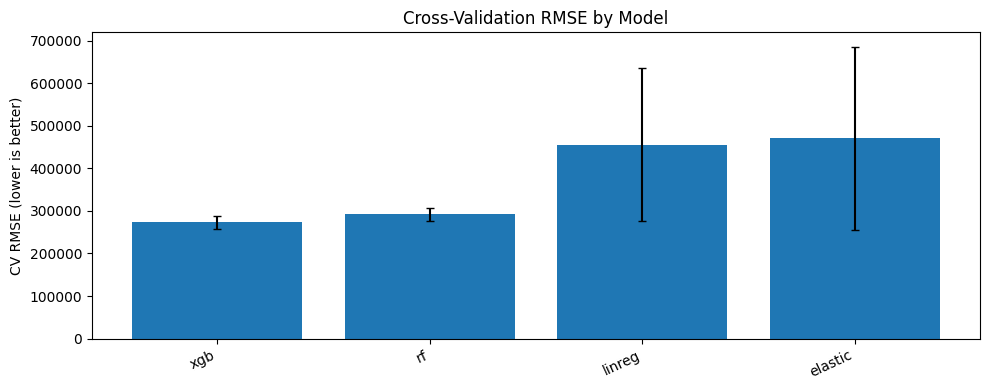

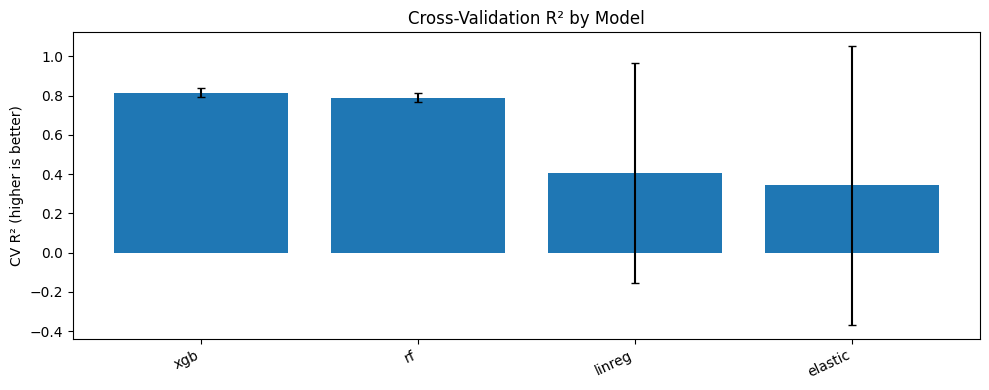

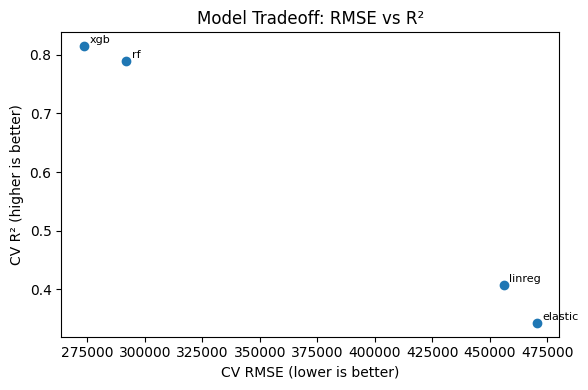

In [10]:
out_dir = Path("artifacts")
out_dir.mkdir(exist_ok=True)

rmse_std = results["rmse_std"] if "rmse_std" in results.columns else None
r2_std = results["r2_std"] if "r2_std" in results.columns else None

plt.figure(figsize=(10, 4))
plt.bar(results["model"], results["rmse"], yerr=rmse_std, capsize=3)
plt.xticks(rotation=25, ha="right")
plt.ylabel("CV RMSE (lower is better)")
plt.title("Cross-Validation RMSE by Model")
plt.tight_layout()
plt.savefig(out_dir / "cv_rmse_by_model.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(results["model"], results["r2"], yerr=r2_std, capsize=3)
plt.xticks(rotation=25, ha="right")
plt.ylabel("CV R² (higher is better)")
plt.title("Cross-Validation R² by Model")
plt.tight_layout()
plt.savefig(out_dir / "cv_r2_by_model.png", dpi=150)
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(results["rmse"], results["r2"])
for _, row in results.iterrows():
    plt.annotate(row["model"], (row["rmse"], row["r2"]), fontsize=8, xytext=(4, 2), textcoords="offset points")
plt.xlabel("CV RMSE (lower is better)")
plt.ylabel("CV R² (higher is better)")
plt.title("Model Tradeoff: RMSE vs R²")
plt.tight_layout()
plt.savefig(out_dir / "cv_rmse_vs_r2.png", dpi=150)
plt.show()

* **XGBoost (best):**
  * **RMSE ≈ 274k** and **R² ≈ 0.81** means the model explains about **81%** of the variance in prices on average across folds, and the typical prediction error scale is about **$274k**.
  * The **std across folds** (RMSE std ≈ 38k, R² std ≈ 0.028) is moderate, which suggests performance is fairly stable across different splits.

* **Random Forest (close second):**
  * **RMSE ≈ 292k**, **R² ≈ 0.79**. It is slightly worse than XGB, but still strong.
  * Similar fold variability to XGB, so it’s also stable.

* **Linear Regression / ElasticNet (much weaker):**
  * **RMSE ≈ 456–470k**, **R² ≈ 0.41–0.34**.
  * This gap is meaningful: a linear model with one-hot features cannot capture many **nonlinear interactions** (e.g., location × rooms × land size × type). Tree-based methods capture these naturally.
  * ElasticNet being slightly worse than plain linear regression is plausible because the regularization can underfit if the chosen `alpha/l1_ratio` is not optimal.

What this implies:
* **Model ranking makes sense**: tree boosting > bagged trees > linear.
* **The magnitude of RMSE is also plausible** for this dataset because prices have a wide range and heavy tails; even good models often have errors in the hundreds of thousands.


## Evaluate best pipeline on held-out test set

We evaluate the selected best pipeline on the held-out test split.


In [11]:
best_pipe = bundle["best"]["pipeline"]

X_test = test_df.drop(columns=["Price"], errors="ignore")
y_test = test_df["Price"].astype(float)

pred = best_pipe.predict(X_test)
rmse = math.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Best model:", bundle["best"]["name"])
print("CV RMSE:", round(bundle["best"]["rmse"], 2), "CV R2:", round(bundle["best"]["r2"], 4))
print("TEST RMSE:", round(rmse, 2), "TEST R2:", round(r2, 4))

Best model: xgb
CV RMSE: 273523.73 CV R2: 0.8149
TEST RMSE: 247235.91 TEST R2: 0.855


## Save artifacts

This writes:

- `artifacts/model.joblib`
- `artifacts/metrics.json`
- `artifacts/cv_results.csv`
- plots: `cv_rmse_by_model.png`, `cv_r2_by_model.png`, `cv_rmse_vs_r2.png`


In [12]:
save_artifacts(bundle, outdir="artifacts")
print("Wrote artifacts/model.joblib and artifacts/metrics.json")

sorted([p.name for p in Path("artifacts").glob("*")])

Wrote artifacts/model.joblib and artifacts/metrics.json


['cv_r2_by_model.png',
 'cv_results.csv',
 'cv_rmse_by_model.png',
 'cv_rmse_vs_r2.png',
 'metrics.json',
 'model.joblib',
 'predictions_sample.csv']